# RL model with perturbation

# Stop the pump

 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  2.9169614843504252


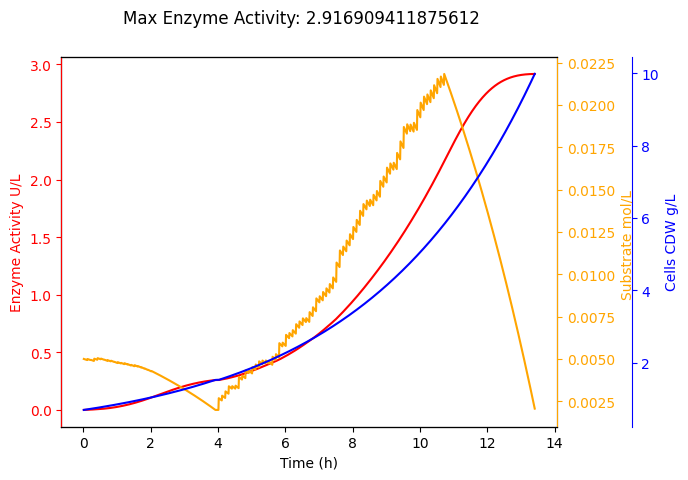

Initial substrate to cell ratio:  0.0071428571428571435


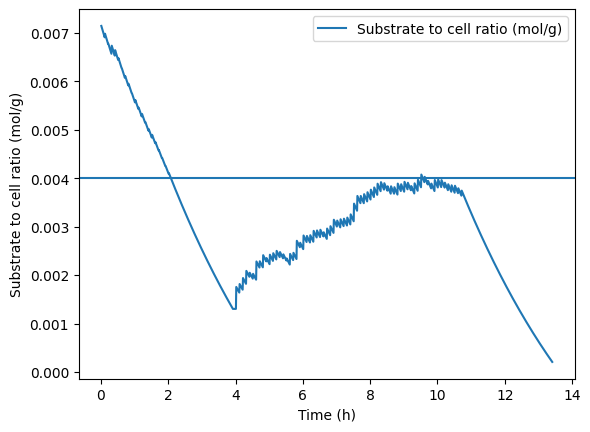

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG
import utils


data_rl_2 = {
    'timestep': [],
    'dxdt' : [],
    'delE':[]
}
experiment_name = "sac_cn10cb100_df"
experiment_folder = os.path.join("experiments",experiment_name)
best_model_folder = os.path.join(experiment_folder, "model" )
best_model_path = os.path.join(best_model_folder, "best_model.zip")

if 'ppo' in experiment_name:
    loaded_model = PPO.load(best_model_path)
elif 'sac' in experiment_name:
    loaded_model = SAC.load(best_model_path)
elif 'ddpg' in experiment_name:
    loaded_model = DDPG.load(best_model_path)


weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)
# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol
flow_rates= []
# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0
for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    # if i == (5/del_t):
    #     T = 38
    # elif i >= (8/del_t):
    #     T = T_opt
    # temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))


    MuX = utils.cell_growth_rate_test(S,mu_max)
    # new cells that are generated

    MuX = MuX #* temp_dep

    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate

    if i > (2/del_t) and i < (4/del_t):
        pass
    else:
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                flow_rates.append(substrate_action)
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration
            else:
                flow_rates.append(0)
        else:
            flow_rates.append(0)
    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    data_rl_2["timestep"].append(i)
    data_rl_2['dxdt'].append(dXdt)
    data_rl_2['delE'].append(delE)

    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
S_C_R = (S/X)

rl_df = pd.DataFrame(data_rl_2)
rl_df.to_csv("rl2_data.csv")

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots()
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")
fig.suptitle(f"Max Enzyme Activity: {max(E)}")
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (h)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
print("Initial substrate to cell ratio: ",S_C_R[0])
plt.axhline(y=config.OPT_SUB_CELL_RATIO)
plt.xlabel("Time (h)")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()

# plt.plot(tvec[:len(flow_rates)], flow_rates, label="MuX = 0.1")
# plt.xlabel("Time")
# plt.ylabel("Flow Volume")
# plt.legend()

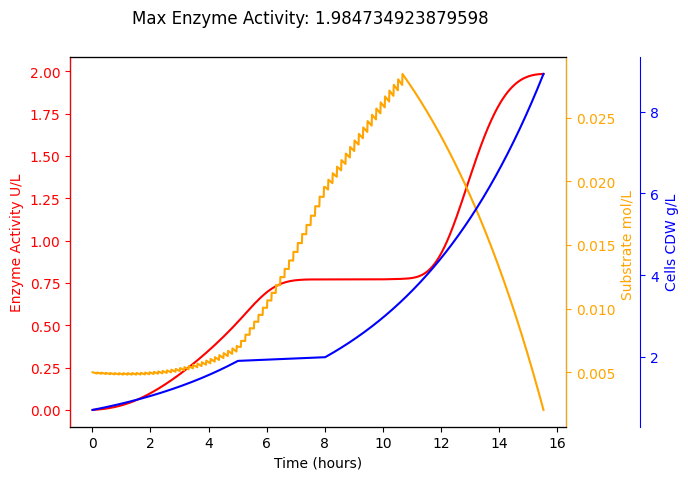

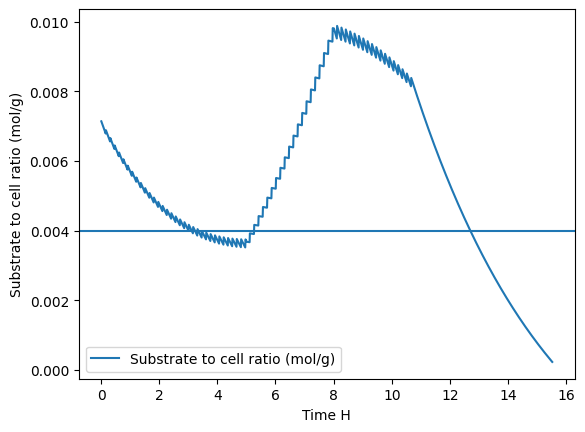

In [3]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np


weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)



tc_e_activities = []
tc_scr = []

start_flow_volume = 0.0008892908583470567
feed_interval = 0.15295954782159268
ramp_factor = 0.05983974644980618
initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor
# Initial conditions
X0 = 0.7  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max =  config.MU_MAX  # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME
substrate_actions = []
# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    if i == (5/del_t):
        T = 38
    elif i >= (8/del_t):
        T = T_opt

    temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))

    MuX = utils.cell_growth_rate(S)

    MuX = MuX * temp_dep
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX

    # Find change in substrate
    delS = dSdt * del_t

    # if i > (8/del_t) and i < (10/del_t):
    #     pass
    # else:
    #     # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            substrate_actions.append(substrate_action)
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration


    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
S_C_R = (S/X)


'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")
fig.suptitle(f"Max Enzyme Activity: {max(E)}")
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO)
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()


In [40]:
import numpy as np

initial_cell_concs = np.linspace(0 , 1, 10)

# RL model perturbation in cells

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG
import utils

experiment_name = "sac_c10n-1"
experiment_folder = os.path.join("experiments",experiment_name)
best_model_folder = os.path.join(experiment_folder, "model" )
best_model_path = os.path.join(best_model_folder, "best_model.zip")

if 'ppo' in experiment_name:
    loaded_model = PPO.load(best_model_path)
elif 'sac' in experiment_name:
    loaded_model = SAC.load(best_model_path)
elif 'ddpg' in experiment_name:
    loaded_model = DDPG.load(best_model_path)


weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

e_activities = []
s_x_ratios = []

for X0 in initial_cell_concs:
    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)
    # Initial conditions
    X0 = X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0
    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        # if i == (3/del_t):
        #     T = 38
        # elif i >= (7/del_t):
        #     T = T_opt
        # temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))


        MuX = utils.cell_growth_rate(S)
        # new cells that are generated

        MuX = MuX #* temp_dep

        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
        
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    S_C_R = (S/X)
    e_activities.append(E[-1])
    s_x_ratios.append(utils.calculate_rmse(S_C_R, config.OPT_SUB_CELL_RATIO))


C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_26172\1321268748.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_26172\1321268748.py:153: RuntimeWarning: divide by zero encountered in divide
  S_C_R = (S/X)


# Traditional Controller perturbation on cells

In [42]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)

tc_e_activities = []
tc_scr = []

for X0 in initial_cell_concs:

    start_flow_volume = 0.0008892908583470567
    feed_interval = 0.15295954782159268
    ramp_factor = 0.05983974644980618

    initial_volume = start_flow_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor


    # Initial conditions
    X0 = X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max =  config.MU_MAX  # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME
    substrate_actions = []
    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        # if i == (3/del_t):
        #     T = 38
        # elif i >= (7/del_t):
        #     T = T_opt
        
        #temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))

        MuX = utils.cell_growth_rate_test(S,mu_max)

        MuX = MuX #* temp_dep
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                substrate_actions.append(substrate_action)
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration


        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break


    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    S_C_R = (S/X)
    tc_e_activities.append(E[-1])
    tc_scr.append(utils.calculate_rmse(S_C_R, config.OPT_SUB_CELL_RATIO))

print(tc_e_activities)

[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.1483891380645606), np.float64(1.323089894773275), np.float64(2.352436412164881), np.float64(3.1832772837567145), np.float64(3.0515239887460863), np.float64(2.459929070436768), np.float64(1.818772627606564)]


C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_26172\3417822431.py:128: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_26172\3417822431.py:150: RuntimeWarning: divide by zero encountered in divide
  S_C_R = (S/X)


# Plotting double bar graph

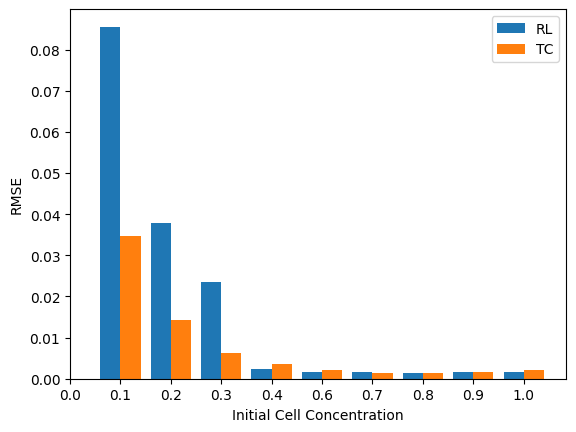

In [43]:
import numpy as np  
import matplotlib.pyplot as plt  
  

X = [round(num, 1) for num in initial_cell_concs]
Y = s_x_ratios 
Z = tc_scr 
  
X_axis = np.arange(len(X)) 
  
plt.bar(X_axis - 0.2, Y, 0.4, label = 'RL') 
plt.bar(X_axis + 0.2, Z, 0.4, label = 'TC') 
  
plt.xticks(X_axis, X) 
plt.xlabel("Initial Cell Concentration") 
plt.ylabel("RMSE") 
plt.legend() 
plt.show()

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_26172\597671043.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_26172\597671043.py:148: RuntimeWarning: divide by zero encountered in divide
  S_C_R = (S/X)


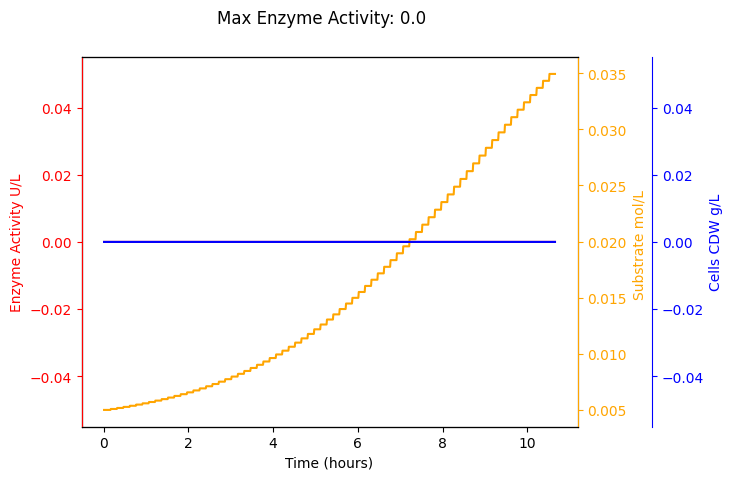

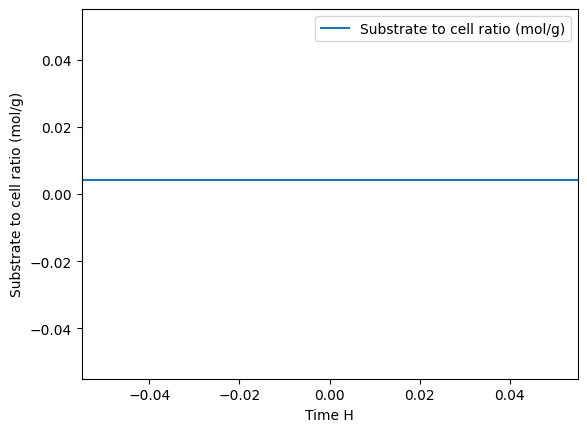

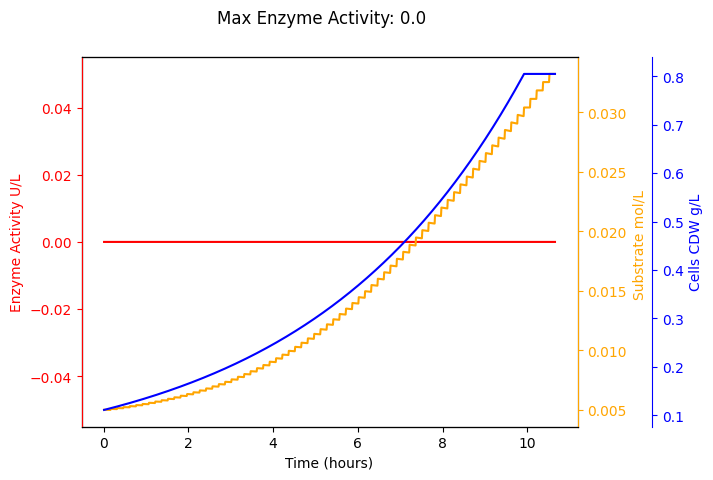

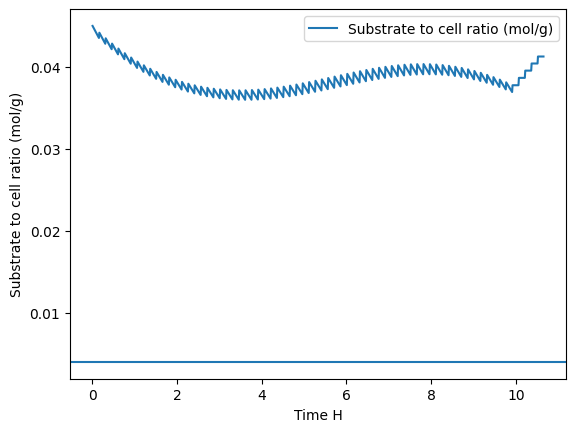

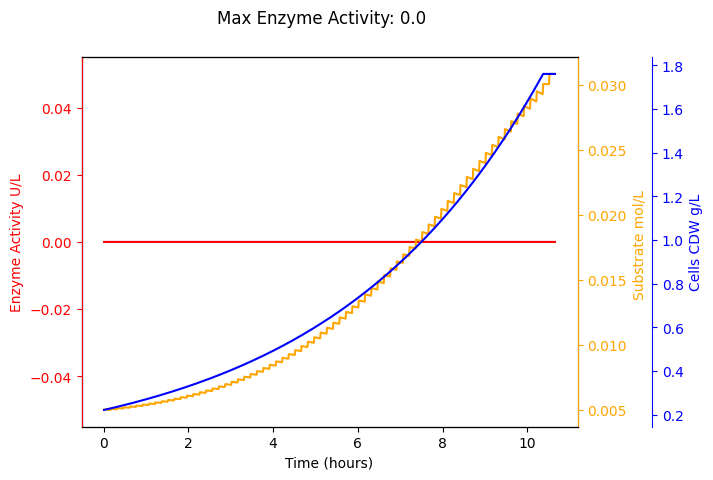

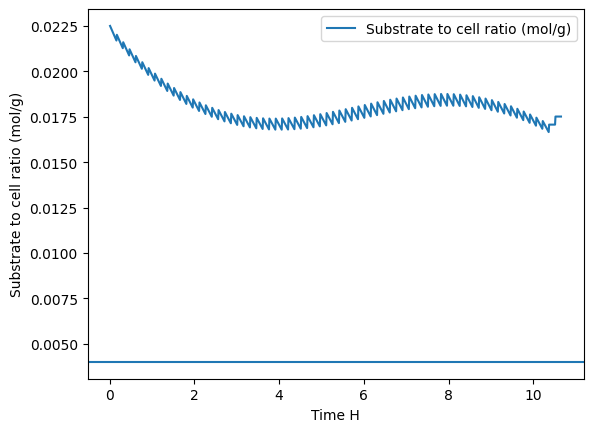

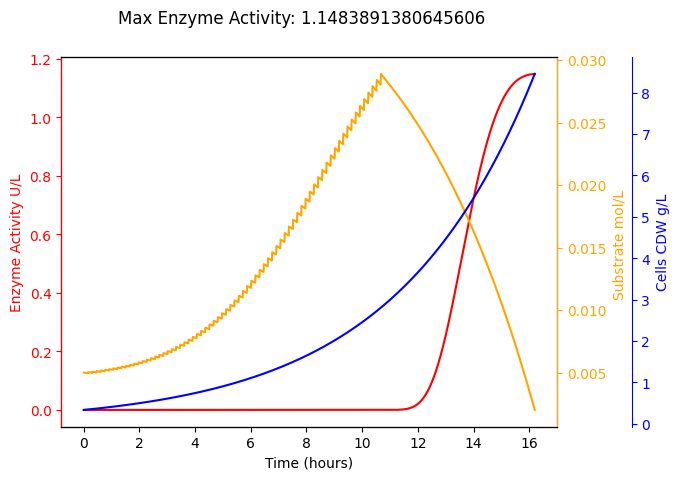

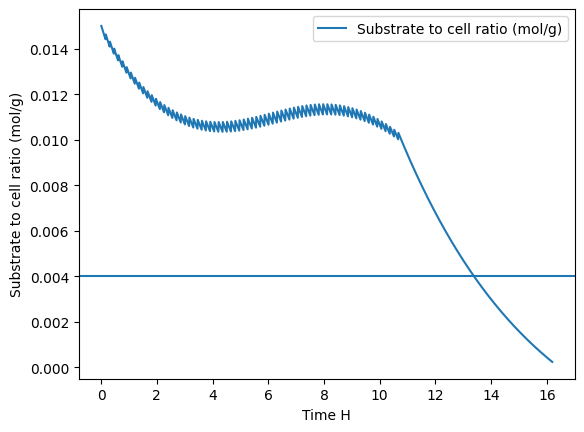

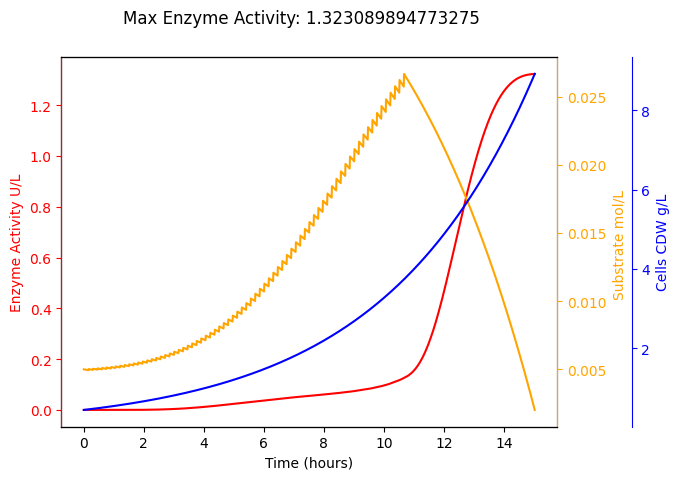

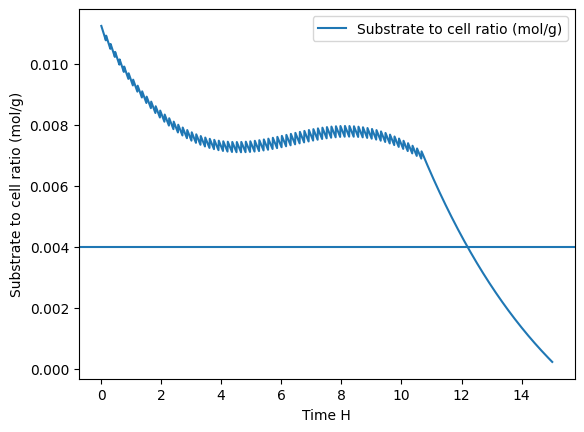

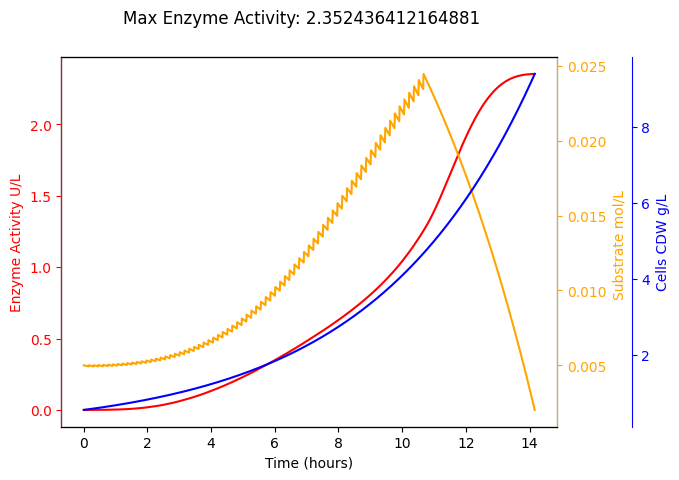

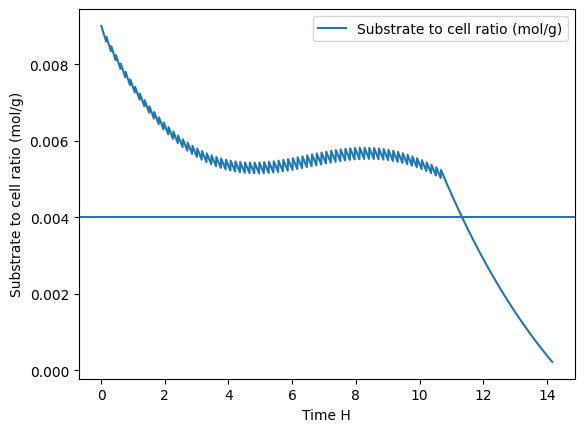

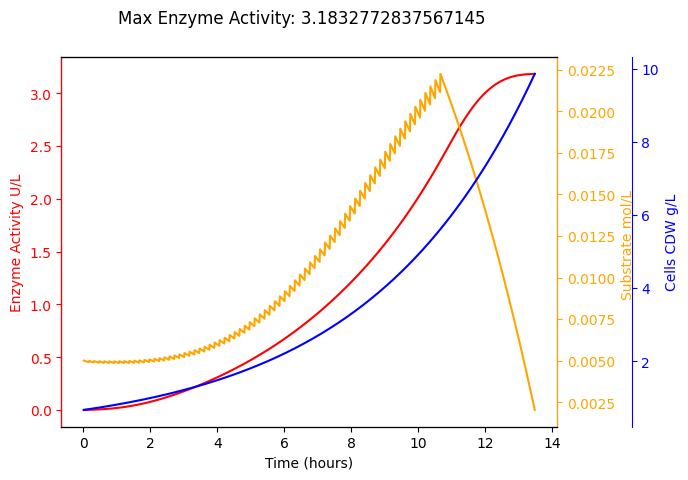

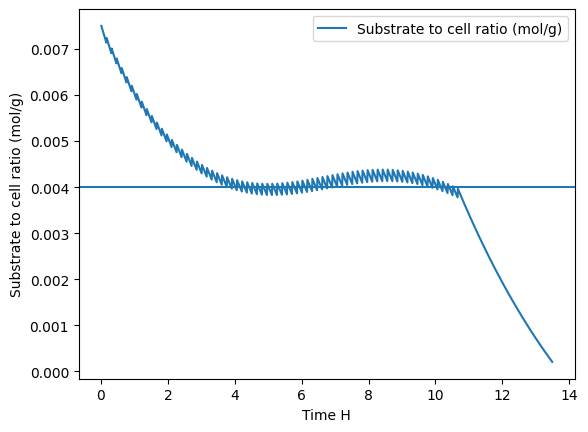

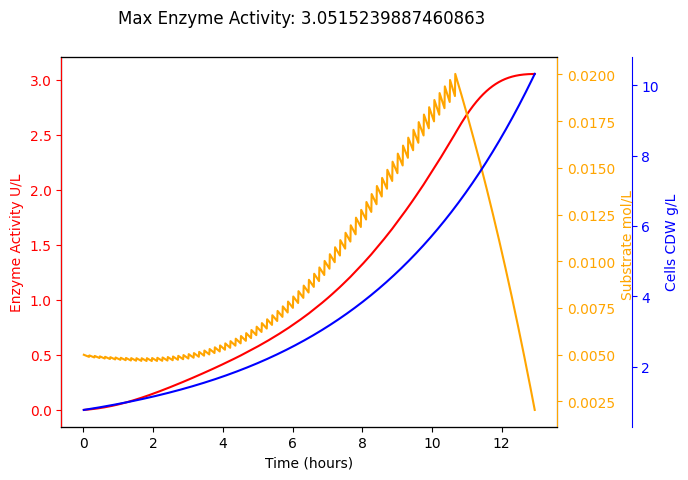

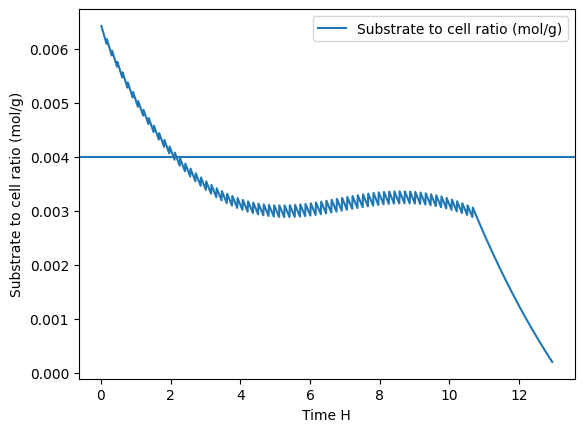

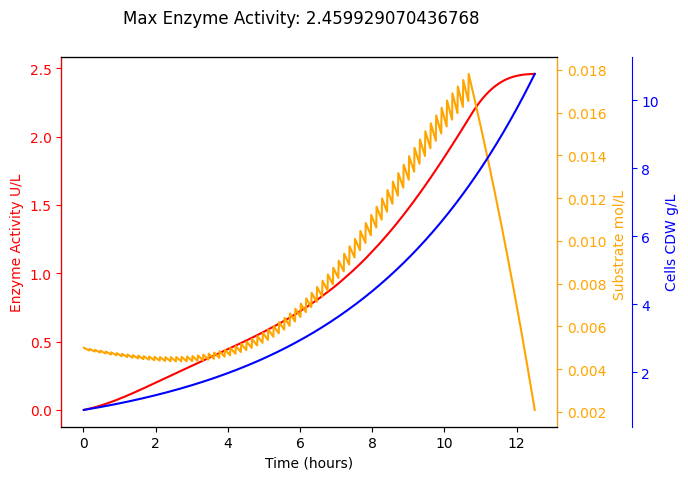

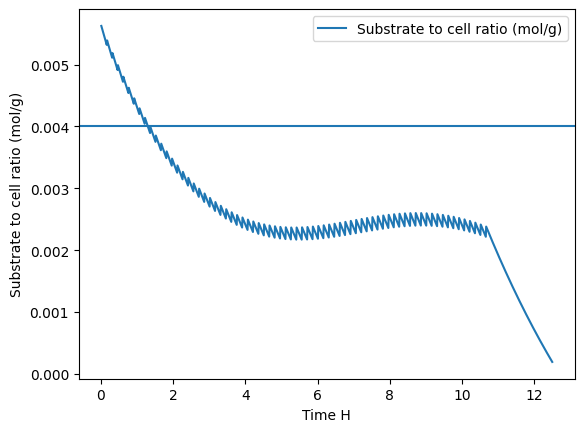

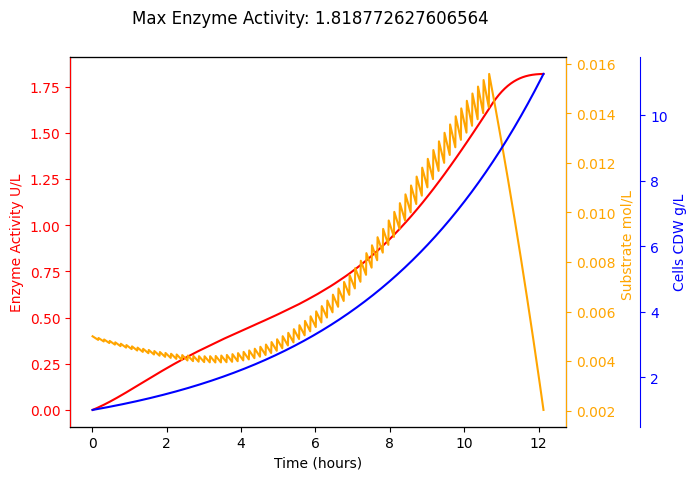

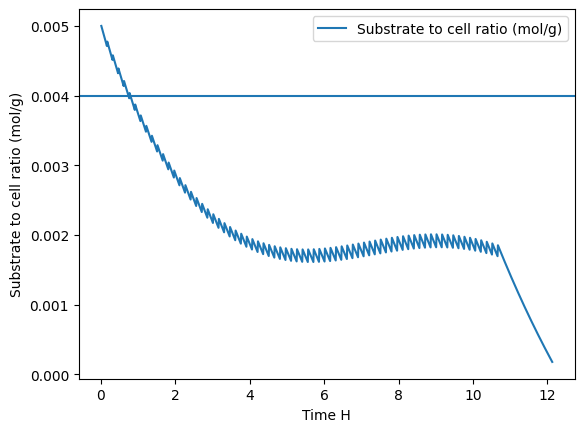

In [44]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np


weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)



tc_e_activities = []
tc_scr = []
for i in initial_cell_concs:
    
    start_flow_volume = 0.0008892908583470567
    feed_interval = 0.15295954782159268
    ramp_factor = 0.05983974644980618
    initial_volume = start_flow_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor
    # Initial conditions
    X0 = i  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max =  config.MU_MAX  # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME
    substrate_actions = []
    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        # if i == (3/del_t):
        #     T = 38
        # elif i >= (7/del_t):
        #     T = T_opt

        #temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))

        MuX = utils.cell_growth_rate(S)

        MuX = MuX #* temp_dep
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX

        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                substrate_actions.append(substrate_action)
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration


        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
        
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    S_C_R = (S/X)


    '''
    ================================================================================================================================================
                                                        Plotting      
    ================================================================================================================================================
    '''

    fig, ax1 = plt.subplots()
    ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")
    fig.suptitle(f"Max Enzyme Activity: {max(E)}")
    ax2 = ax1.twinx()
    ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

    ax3 = ax1.twinx()
    ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
    #ax3.spines['right'].set_position(('outward',60))
    ax3.spines['right'].set_position(('axes',1.15))

    ax1.set_ylabel("Enzyme Activity U/L", color="red")
    ax1.set_xlabel("Time (hours)")
    ax2.set_ylabel("Substrate mol/L ", color="orange")
    ax3.set_ylabel("Cells CDW g/L", color="blue")

    ax1.tick_params(axis='y',colors="red")
    ax2.tick_params(axis='y',colors="orange")
    ax3.tick_params(axis='y',colors="blue")

    ax2.spines['right'].set_color("orange")
    ax3.spines['right'].set_color("blue")
    ax3.spines['left'].set_color("red")
    #fig.legend()
    plt.show()

    plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
    plt.axhline(y=config.OPT_SUB_CELL_RATIO)
    plt.xlabel("Time H")
    plt.ylabel("Substrate to cell ratio (mol/g)")
    plt.legend()
